**PROJETO 1**

In [42]:
import math
import pandas as pd
import numpy as np

**Variável com a planilha**

In [43]:
arquivo = 'Dados Habitacionais de Ames.xlsx'

**Datasheet da planilha**

Pra editar no python

In [44]:
df = pd.read_excel(arquivo)

**Classificação das variáveis**
- Sale Price (Preço de venda) - quantitativo contínuo
- Lot area (Área do lote) - quantitativo contínuo
- neighborhood (bairro) - qualitativo nominal

In [ ]:
df1 = df.Neighborhood.value_counts()

Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64

**CONVERTER DADOS PARA DATAFRAME**

In [46]:
dadosvquali = pd.DataFrame(df1)

**TOTAL DOS DADOS**

Temos 2930 linhas

In [47]:
Totalcasas = df1.sum()
Totalcasas

np.int64(2930)

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

Regra de sturges para descobrir numero de intervalos do histograma

In [49]:
math.ceil(1+3.322*math.log10(len(df)))

13

In [50]:
df2 = df.SalePrice.value_counts(bins=13 , sort=False)
df2

(12046.788, 69882.154]        51
(69882.154, 126975.308]      600
(126975.308, 184068.462]    1200
(184068.462, 241161.615]     578
(241161.615, 298254.769]     261
(298254.769, 355347.923]     124
(355347.923, 412441.077]      64
(412441.077, 469534.231]      28
(469534.231, 526627.385]       9
(526627.385, 583720.538]       7
(583720.538, 640813.692]       6
(640813.692, 697906.846]       0
(697906.846, 755000.0]         2
Name: count, dtype: int64

In [51]:
dadosvquanti = pd.DataFrame(df2)
dadosvquanti = dadosvquanti.rename(columns={'count': 'Frequência absoluta'})
dadosvquanti['Frequência %'] = round(dadosvquanti['Frequência absoluta']*100/Totalcasas,2)
dadosvquanti

,Frequência absoluta,Frequência %
"(12046.788, 69882.154]",51,1.74
"(69882.154, 126975.308]",600,20.48
"(126975.308, 184068.462]",1200,40.96
"(184068.462, 241161.615]",578,19.73
"(241161.615, 298254.769]",261,8.91
"(298254.769, 355347.923]",124,4.23
"(355347.923, 412441.077]",64,2.18
"(412441.077, 469534.231]",28,0.96
"(469534.231, 526627.385]",9,0.31
"(526627.385, 583720.538]",7,0.24


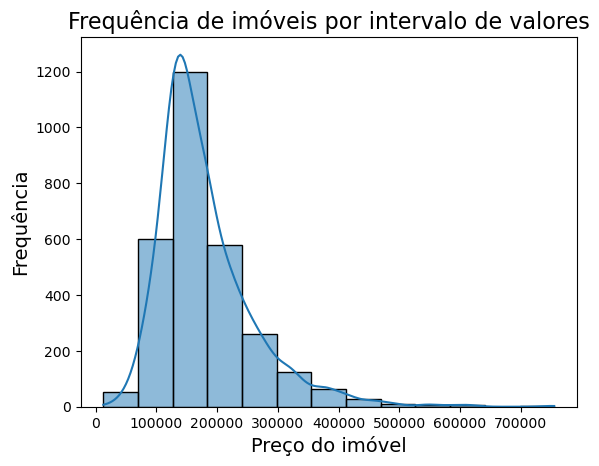

In [52]:
sns.histplot(df.SalePrice, bins=13, kde=True)

plt.title('Frequência de imóveis por intervalo de valores',size=16)
plt.xlabel('Preço do imóvel',size=14)
plt.ylabel('Frequência',size=14)

plt.show()

In [53]:
df3 = df['Lot Area'].value_counts(bins=13, sort=False)
df3

(1086.054, 17757.308]       2804
(17757.308, 34214.615]        98
(34214.615, 50671.923]        16
(50671.923, 67129.231]         7
(67129.231, 83586.538]         1
(83586.538, 100043.846]        0
(100043.846, 116501.154]       1
(116501.154, 132958.462]       0
(132958.462, 149415.769]       0
(149415.769, 165873.077]       2
(165873.077, 182330.385]       0
(182330.385, 198787.692]       0
(198787.692, 215245.0]         1
Name: count, dtype: int64

In [54]:
dadosvquanti2 = pd.DataFrame(df3)
dadosvquanti2 = dadosvquanti2.rename(columns={'count': 'Frequência absoluta'})
dadosvquanti2['Frequência %'] = round(dadosvquanti2['Frequência absoluta']*100/Totalcasas,2)
dadosvquanti2

,Frequência absoluta,Frequência %
"(1086.054, 17757.308]",2804,95.70
"(17757.308, 34214.615]",98,3.34
"(34214.615, 50671.923]",16,0.55
"(50671.923, 67129.231]",7,0.24
"(67129.231, 83586.538]",1,0.03
"(83586.538, 100043.846]",0,0.00
"(100043.846, 116501.154]",1,0.03
"(116501.154, 132958.462]",0,0.00
"(132958.462, 149415.769]",0,0.00
"(149415.769, 165873.077]",2,0.07


Text(0, 0.5, 'Frequência')

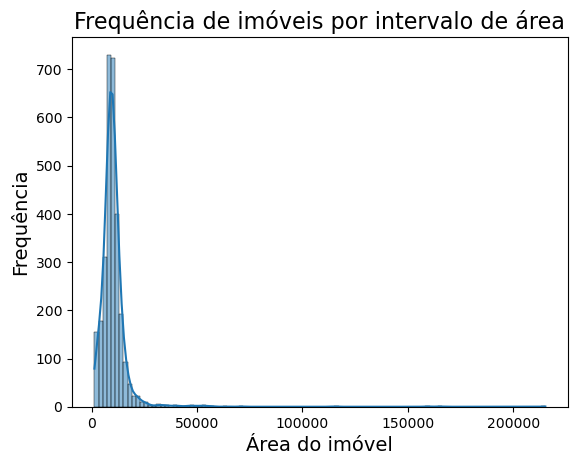

In [55]:
sns.histplot(df['Lot Area'], kde=True)

plt.title('Frequência de imóveis por intervalo de área',size=16)
plt.xlabel('Área do imóvel',size=14)
plt.ylabel('Frequência',size=14)

Os intervalos ficaram ruins por conta dos outliers, devemos retiralos e descobrir os limites sem eles através dos quartis

In [56]:
Q1 = df['Lot Area'].quantile(.25)
Q3 = df['Lot Area'].quantile(.75)
IIQ = Q3 - Q1
limite_inferior = Q1 - 1.5 * IIQ
limite_superior = Q3 + 1.5 * IIQ

In [57]:
quartis = pd.DataFrame([Q1, Q3, IIQ, limite_inferior, limite_superior], index=['Q1', 'Q3', 'IIQ', 'Limite inferior', 'Limite superior'], columns=['Valores'])
quartis

,Valores
Q1,7440.25
Q3,11555.25
IIQ,4115.00
Limite inferior,1267.75
Limite superior,17727.75


Text(0, 0.5, 'Frequência')

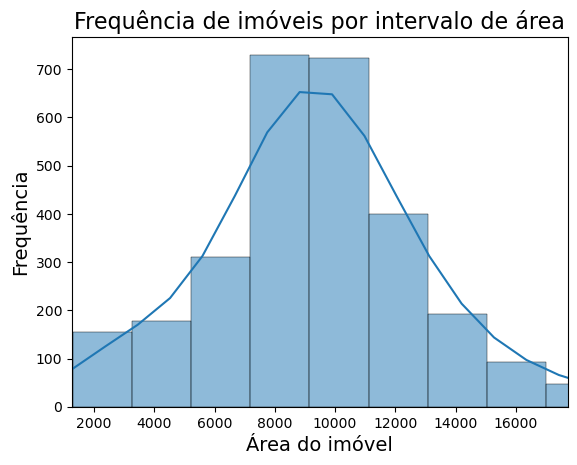

In [58]:
sns.histplot(df['Lot Area'], kde=True)
plt.xlim(limite_inferior, limite_superior)
plt.title('Frequência de imóveis por intervalo de área',size=16)
plt.xlabel('Área do imóvel',size=14)
plt.ylabel('Frequência',size=14)

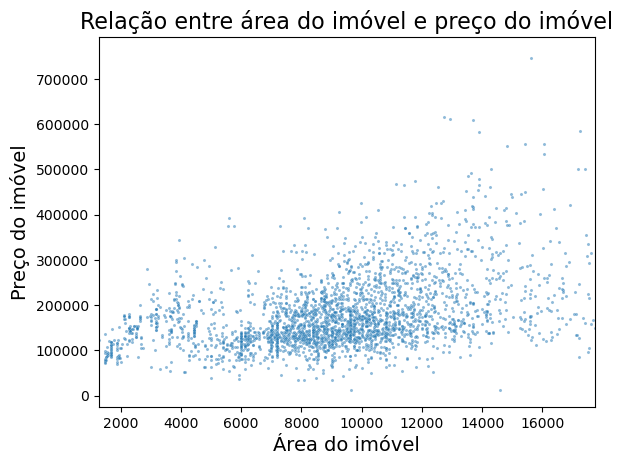

In [59]:
sns.scatterplot(x='Lot Area', y='SalePrice', data=df, alpha=0.5, s=5)
plt.xlim(limite_inferior, limite_superior)
plt.title('Relação entre área do imóvel e preço do imóvel',size=16)
plt.xlabel('Área do imóvel',size=14)
plt.ylabel('Preço do imóvel',size=14)

plt.show()

Podemos ver que a coorenlação entre o tamanho do imóvel e o preço dele tem uma relação fraca (os pontos ficam dispersos)


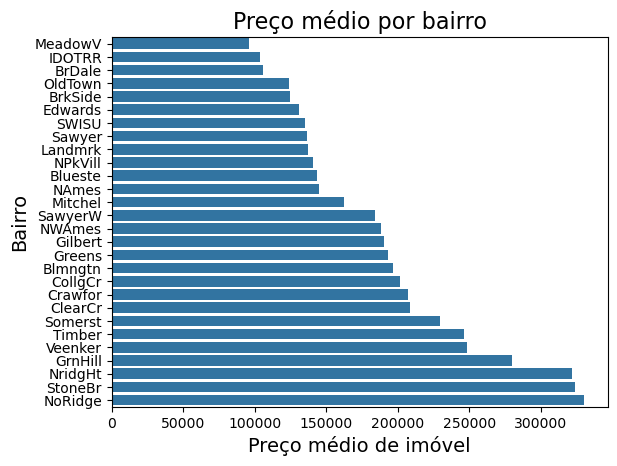

In [60]:
media = df.groupby('Neighborhood')['SalePrice'].mean().sort_values()

sns.barplot(y=media.index, x=media)

plt.title('Preço médio por bairro',size=16)
plt.ylabel('Bairro',size=14)
plt.xlabel('Preço médio de imóvel',size=14)

plt.show()

Medidas resumo do valor de venda:
Média e Amplitude

In [61]:
print('Média de preços:',df['SalePrice'].mean())
print('Amplitude de preços:',df['SalePrice'].max()-df['SalePrice'].min())

Média de preços: 180796.0600682594
Amplitude de preços: 742211


Medidas resumo da área: Média e Amplitude

In [62]:
print('Média de área:',df['Lot Area'].mean())
print('Amplitude de área:',df['Lot Area'].max()-df['Lot Area'].min())

Média de área: 10147.921843003413
Amplitude de área: 213945


Medidas resumo do bairro: Moda e

In [ ]:
print('Moda:', df1.idxmax(), '| Frequência: ',df1.max())


Moda: NAmes | Frequência:  443
